In [17]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

import qiskit

import sys
sys.path.insert(0, '../')

import oasis_dla

In [18]:
def linear_indep(mats: list[np.ndarray]) -> bool:
    vecs = [m.flatten() for m in mats]
    M = np.column_stack(vecs)
    rank = np.linalg.matrix_rank(M)
    return rank == M.shape[1]

def commutator(A: np.ndarray, B: np.ndarray) -> np.ndarray:
    return A @ B - B @ A

def construct_dla(generators):
    dla = [] # init empty dla to start

    # go through initial generators
    for gen in generators:
        # print(type(gen))
        pot_dla = [*dla, gen]
        print(pot_dla)
        if linear_indep(pot_dla):
            dla = pot_dla

    # now we're left w all the linear indep generators 
    # go thru all combinations of generators and compute brackets, find
    l = 1
    r = 0

    while l < len(dla):
        for m in range(r):
            bracket = commutator(dla[l], dla[m])
            pot_dla = [*dla, bracket]
            if linear_indep(pot_dla):
                dla = pot_dla
        r += 1
        if r == l:
            l += 1
            r = 0

    return dla
         




In [19]:
circuit = qiskit.QuantumCircuit(1)
circuit.h(0)
circuit.ry(0, 0)

gen = oasis_dla.extract_generators(circuit)

display(gen)

X = qiskit.circuit.library.XGate().to_matrix()
Y = qiskit.circuit.library.YGate().to_matrix()
Z = qiskit.circuit.library.ZGate().to_matrix()

dla = construct_dla(gen)

print(f"Computed DLA: \n{dla}")
print(f"dim(g): {len(dla)}")

[array([[-1.+0.j,  1.+0.j],
        [ 1.+0.j,  1.+0.j]]),
 array([[0.+0.j, 0.-1.j],
        [0.+1.j, 0.+0.j]])]

[array([[-1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j]])]
[array([[-1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j]]), array([[0.+0.j, 0.-1.j],
       [0.+1.j, 0.+0.j]])]
Computed DLA: 
[array([[-1.+0.j,  1.+0.j],
       [ 1.+0.j,  1.+0.j]]), array([[0.+0.j, 0.-1.j],
       [0.+1.j, 0.+0.j]])]
dim(g): 2


In [20]:
print(f"Var(cost) ~ 1/dim(g) = {1/len(dla)}")

Var(cost) ~ 1/dim(g) = 0.5


In [21]:
vqls = oasis_dla.VQLS()

A = np.array([
    [1, 1],
    [1, 1]
])

b = np.array([
    [1],
    [-1]
])

X = np.array([
    [0, 1],
    [1, 0]
])

Y = np.array([
    [0, -1j],
    [1j, 0]
])

Z = np.array([
    [1, 0],
    [0, -1]
])

# pauli_matrices = [np.eye(2), X, Y, Z]
# coeffs = [0.5 * np.trace(P @ A) for P in pauli_matrices]

# sum = np.zeros((2, 2), np.complex128)
# for i, p in enumerate(pauli_matrices):
#     sum += (coeffs[i] * p)
# sum

solution = vqls.solve(A, b, shots=10_000)

print(solution.rescale_answer())
solution.get_probabilities()
print(np.linalg.solve(A, b))


ValueError: Empty observable was detected.

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -2.220446049250313e-16
       x: [-2.498e+00]
     nit: 39
   maxcv: 0.0
    nfev: 22
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 2.220446049250313e-16
       x: [-2.498e+00]
     nit: 40
   maxcv: 0.0
    nfev: 22
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 9.43689570931383e-15
       x: [-2.498e+00]
     nit: 41
   maxcv: 0.0
    nfev: 22
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 9.57012247226885e-14
       x: [-2.498e+00]
     nit: 36
   maxcv: 0.0
    nfev: 23
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: -4.440892098500626e-16
       x: [-2.498e+00]
     nit: 43
   maxcv: 0.0
    nfev: 23
 message: The lower bound for the t

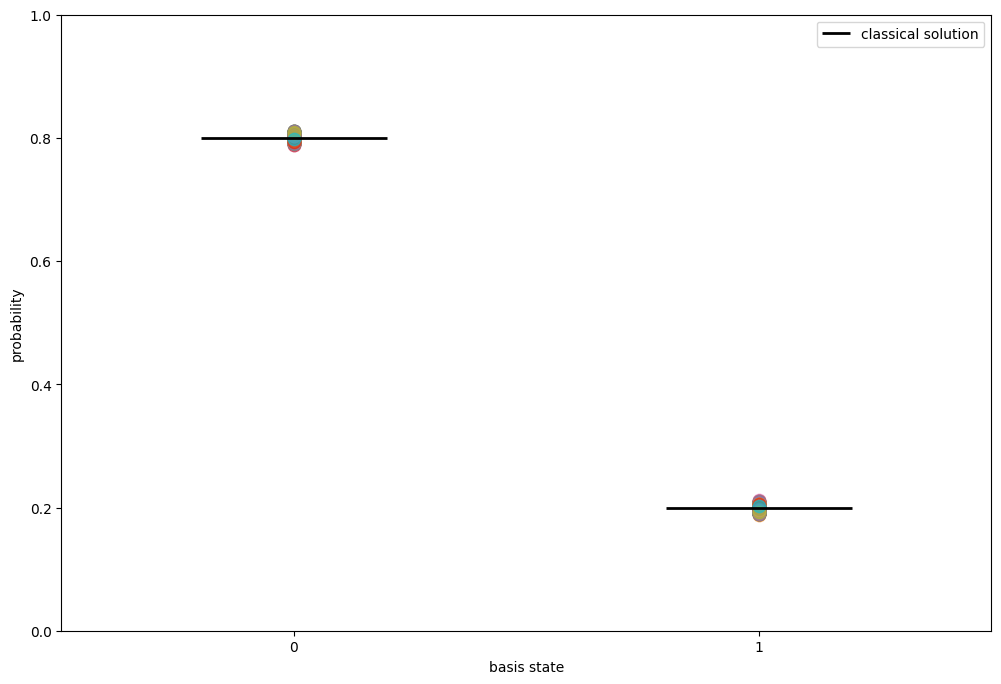

In [ ]:
prob_list = []
for i in range(0, 100):
    res = vqls.solve(A, b)
    prob_list.append(res.get_probabilities())

print(prob_list)

# classical solution -> probabilities |x_i|^2 / ||x||^2
x_classical = np.linalg.solve(A, b).reshape(-1)
p_classical = np.abs(x_classical)**2 / np.sum(np.abs(x_classical)**2)
print(f"classical probabilities: {p_classical}")

fig, ax = plt.subplots(figsize=(12, 8))
# short horizontal line centered on each basis state at its classical probability
ax.hlines(p_classical, [-0.2, 0.8], [0.2, 1.2], colors="black", linewidth=2, label="classical solution")

for probs in prob_list:
    p = [probs.get("0", 0), probs.get("1", 0)]
    ax.scatter([0, 1], p)

ax.set_xticks([0, 1])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1)
ax.set_xlabel("basis state")
ax.set_ylabel("probability")
ax.legend()
plt.show()

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 2.220446049250313e-16
       x: [-2.498e+00]
     nit: 42
   maxcv: 0.0
    nfev: 21
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 9.514611321037592e-14
       x: [-2.498e+00]
     nit: 36
   maxcv: 0.0
    nfev: 23
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 0.0
       x: [-2.498e+00]
     nit: 38
   maxcv: 0.0
    nfev: 23
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 5.551115123125783e-16
       x: [-2.498e+00]
     nit: 38
   maxcv: 0.0
    nfev: 20
 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 5.551115123125783e-16
       x: [-2.498e+00]
     nit: 44
   maxcv: 0.0
    nfev: 23
 message: The lower bound for the trust-region radius

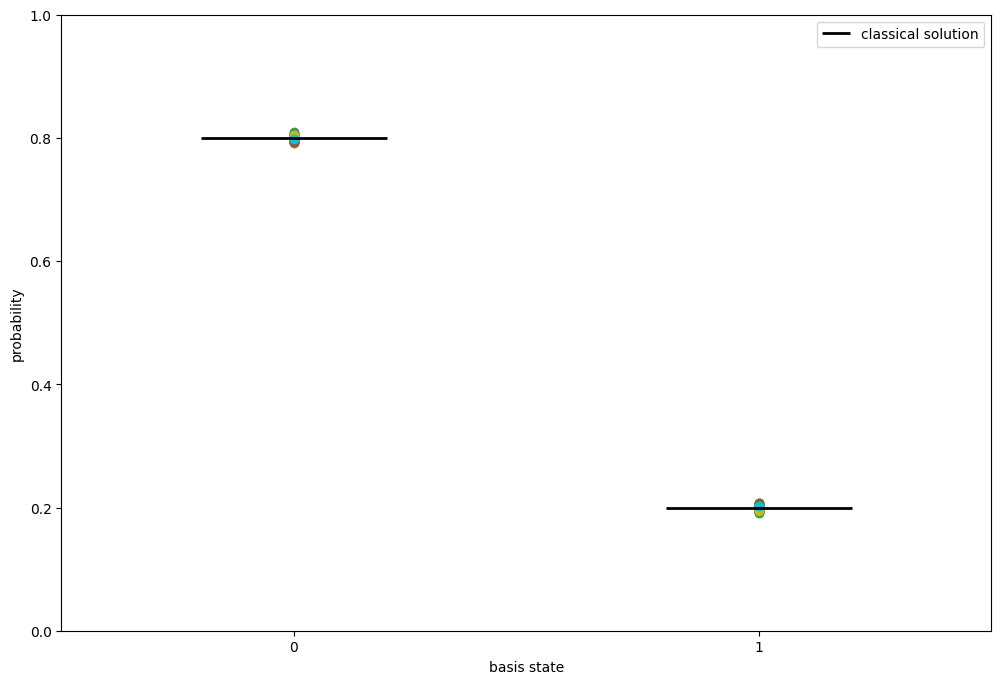

In [ ]:
prob_list = []
for i in range(0, 100):
    res = vqls.solve(A, b)
    prob_list.append(res.get_probabilities())

print(prob_list)

# classical solution -> probabilities |x_i|^2 / ||x||^2
x_classical = np.linalg.solve(A, b).reshape(-1)
p_classical = np.abs(x_classical)**2 / np.sum(np.abs(x_classical)**2)
print(f"classical probabilities: {p_classical}")

fig, ax = plt.subplots(figsize=(12, 8))
# short horizontal line centered on each basis state at its classical probability
ax.hlines(p_classical, [-0.2, 0.8], [0.2, 1.2], colors="black", linewidth=2, label="classical solution")

for probs in prob_list:
    p = [probs.get("0", 0), probs.get("1", 0)]
    ax.scatter([0, 1], p)

ax.set_xticks([0, 1])
ax.set_xlim(-0.5, 1.5)
ax.set_ylim(0, 1)
ax.set_xlabel("basis state")
ax.set_ylabel("probability")
ax.legend()
plt.show()

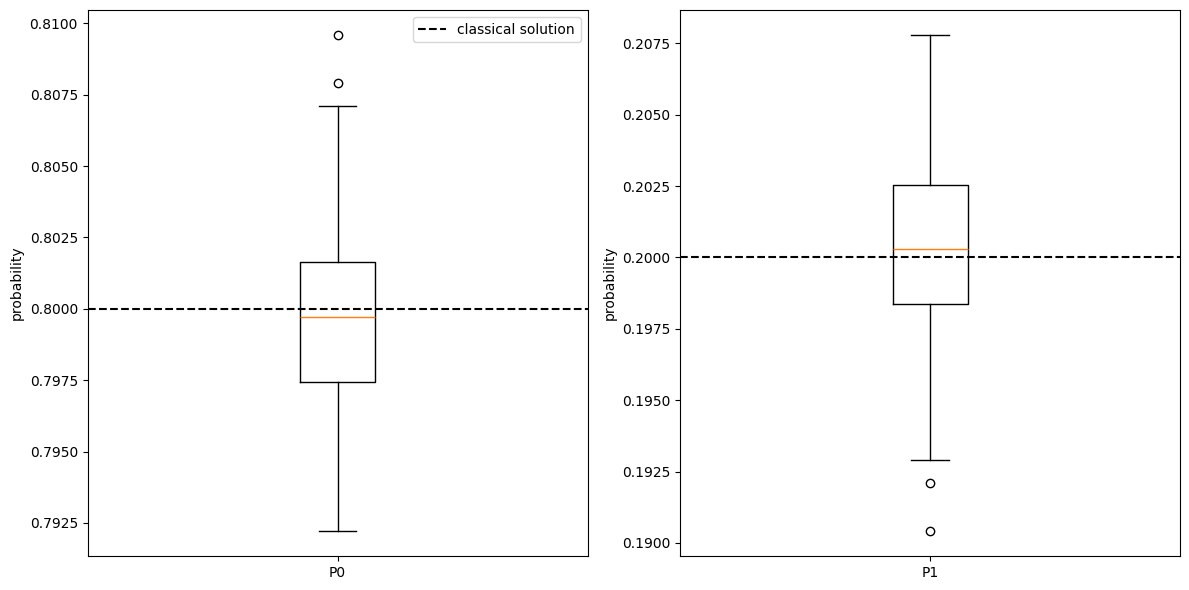

In [ ]:
P0s = [probs.get("0", 0) for probs in prob_list]
P1s = [probs.get("1", 0) for probs in prob_list]

# separate panels: P0 and P1 are ~0.6 apart, so a shared axis would squash both boxes
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, data, p_true, label in zip(axes, [P0s, P1s], p_classical, ["P0", "P1"]):
    ax.boxplot(data)
    ax.axhline(p_true, color="black", linestyle="--", linewidth=1.5, label="classical solution")
    ax.set_xticks([1])
    ax.set_xticklabels([label])
    ax.set_ylabel("probability")

axes[0].legend()
plt.tight_layout()
plt.show()